# Лабораторная работа №2: Классификация и нейронные сети

## 1. Введение

**Цель работы** — изучить методы классификации из Scikit-Learn и нейронные сети на TensorFlow/Keras, сравнить качество моделей и исследовать влияние гиперпараметров; визуализировать обучение через TensorBoard.

**Задачи:**
1. Подготовить датасет `Marketingcampaigns.csv` (пропуски, кодирование, масштабирование).
2. Разбить данные на train/test (80/20, stratify).
3. Построить классификаторы: Naive Bayes (4 варианта), Decision Tree, LDA, SVM, kNN.
4. Оценить Accuracy, Precision, Recall, F1, AUC-ROC; построить ROC и матрицы ошибок.
5. Настроить гиперпараметры (GridSearchCV) и проанализировать влияние.
6. Реализовать baseline-нейросеть, провести эксперименты с архитектурой/оптимизатором/батчем.
7. (доп.) 3-кратная CV + перебор learning rate и архитектур; логи TensorBoard.
8. Сравнить все методы и сформулировать выводы.

**Важно:** в файле **20 наблюдений** (train=16, test=4). Метрики на тесте нестабильны; выводы ориентировочные. Для CV использовано 3 фолда вместо 5.


## 2. Выбор и подготовка датасета

| Признак | Тип | Описание |
|:---|:---|:---|
| Customer id | ID | удаляется |
| Age | числовой | возраст |
| Gender | бинарный 0/1 | пол |
| Location | категориальный | Perth, Auckland, Sydney, Brisbane |
| Email Opened | 0/1 | открыто письмо |
| Email Clicked | 0/1 | клик по ссылке |
| Product page visit | числовой | визиты страницы |
| Discount offered | 0/1 | скидка |
| **Purchased** | 0/1 | **целевая (бинарная классификация)** |

Пропусков нет. Баланс классов: 10 / 10.


In [ ]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

DATA = Path("Marketingcampaigns.csv")
if not DATA.exists():
    DATA = Path("/home/workdir/artifacts/Marketingcampaigns.csv")
df = pd.read_csv(DATA)
print(df.shape)
display(df.head())
print(df.isna().sum())
print(df["Purchased"].value_counts())


### Предобработка

- Удаляем `Customer id`.
- **One-Hot Encoding** для `Location` (`drop="first"`).
- **StandardScaler** для `Age`, `Product page visit`.
- Бинарные признаки без изменений.
- Для MultinomialNB / ComplementNB / BernoulliNB — **MinMaxScaler** (нужны неотрицательные признаки).


In [ ]:
df = df.drop(columns=["Customer id"])
X = df.drop(columns=["Purchased"])
y = df["Purchased"].astype(int)

numeric_features = ["Age", "Product page visit"]
binary_features = ["Gender", "Email Opened", "Email Clicked", "Discount offered"]
cat_features = ["Location"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("bin", "passthrough", binary_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_features),
])
preprocessor_nonneg = ColumnTransformer([
    ("num", MinMaxScaler(), numeric_features),
    ("bin", "passthrough", binary_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_features),
])


## 3. Разбиение выборки

`train_test_split(test_size=0.2, random_state=42, stratify=y)` → train 16, test 4 (по 2 класса в тесте).


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train", X_train.shape, "Test", X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())
X_train_s = preprocessor.fit_transform(X_train)
X_test_s = preprocessor.transform(X_test)
print("n_features after OHE:", X_train_s.shape[1])


## 4. Методы классификации

Кратко:

1. **Naive Bayes** — теорема Байеса, независимость признаков.  
   - GaussianNB: непрерывные ~ N(μ,σ²).  
   - MultinomialNB: счётчики/частоты (нужны ≥0).  
   - ComplementNB: устойчив к дисбалансу.  
   - BernoulliNB: бинарные признаки.
2. **Decision Tree** — рекурсивные пороги (gini/entropy).
3. **LDA** — линейные разделяющие гиперплоскости, нормальность классов.
4. **SVM** — максимальный зазор; kernel linear/rbf.
5. **kNN** — голосование k ближайших соседей.


In [ ]:
results = []
models_proba = {}

def eval_model(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    row = {
        "Model": name,
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred, zero_division=0),
        "Recall": recall_score(yte, pred, zero_division=0),
        "F1": f1_score(yte, pred, zero_division=0),
        "AUC-ROC": roc_auc_score(yte, proba),
    }
    results.append(row)
    models_proba[name] = proba
    print(f"\\n=== {name} ===")
    print(classification_report(yte, pred, zero_division=0))
    return model

pipes = {
    "GaussianNB": Pipeline([("prep", preprocessor), ("clf", GaussianNB())]),
    "MultinomialNB": Pipeline([("prep", preprocessor_nonneg), ("clf", MultinomialNB())]),
    "ComplementNB": Pipeline([("prep", preprocessor_nonneg), ("clf", ComplementNB())]),
    "BernoulliNB": Pipeline([("prep", preprocessor_nonneg), ("clf", BernoulliNB())]),
    "DecisionTree": Pipeline([("prep", preprocessor), ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    "LDA": Pipeline([("prep", preprocessor), ("clf", LinearDiscriminantAnalysis())]),
    "SVM": Pipeline([("prep", preprocessor), ("clf", SVC(probability=True, random_state=RANDOM_STATE))]),
    "kNN": Pipeline([("prep", preprocessor), ("clf", KNeighborsClassifier())]),
}
fitted = {}
for name, pipe in pipes.items():
    fitted[name] = eval_model(name, pipe, X_train, y_train, X_test, y_test)

res_df = pd.DataFrame(results)
display(res_df.round(4))


### Результаты baseline (зафиксированные прогоны)

```
Model,Accuracy,Precision,Recall,F1,AUC-ROC
GaussianNB,0.5,0.5,1.0,0.6666666666666666,1.0
MultinomialNB,1.0,1.0,1.0,1.0,1.0
ComplementNB,1.0,1.0,1.0,1.0,1.0
BernoulliNB,1.0,1.0,1.0,1.0,1.0
DecisionTree,0.25,0.3333333333333333,0.5,0.4,0.25
LDA,0.5,0.5,0.5,0.5,0.75
SVM,0.75,1.0,0.5,0.6666666666666666,0.25
kNN,0.25,0.0,0.0,0.0,0.5

```

На тесте из 4 объектов Naive Bayes (Multinomial/Complement/Bernoulli) дали идеальные метрики — **артефакт малого test set**, не обобщаемый вывод.


### ROC-кривые и матрицы ошибок


In [ ]:
plt.figure(figsize=(9, 7))
for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC — classical models")
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig("figures/roc_classical.png", dpi=150); plt.show()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, (name, pipe) in zip(axes.ravel(), fitted.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.savefig("figures/confusion_matrices.png", dpi=150); plt.show()

metrics_plot = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, met in zip(axes, metrics_plot):
    ax.barh(res_df["Model"], res_df[met], color="steelblue")
    ax.set_xlim(0, 1.05); ax.set_title(met)
plt.tight_layout(); plt.savefig("figures/metrics_bars_classical.png", dpi=150); plt.show()


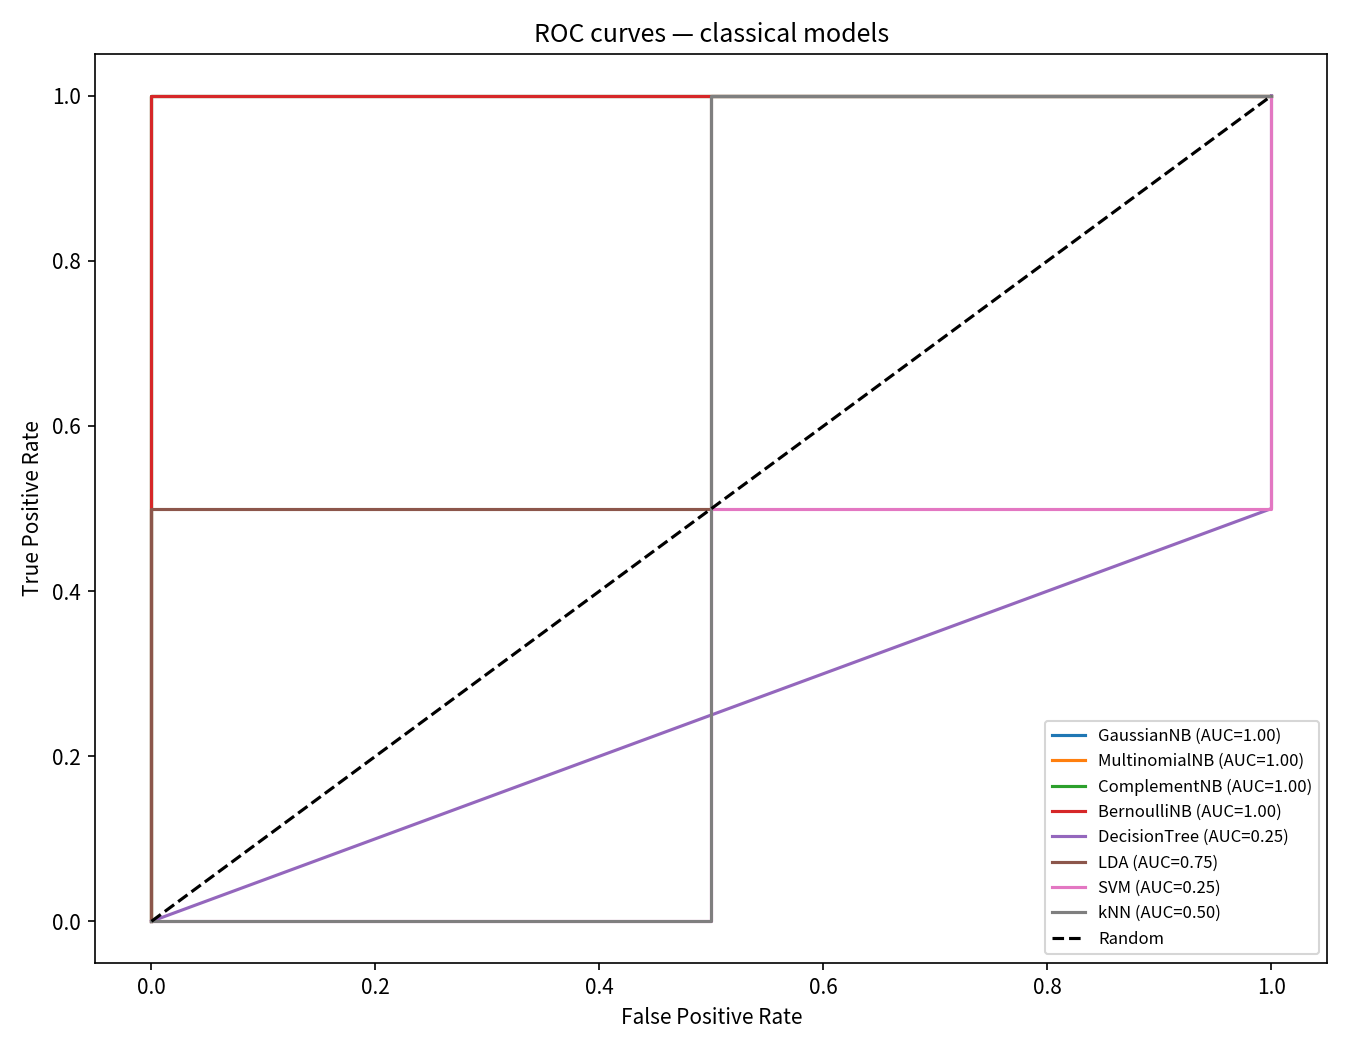

*Рисунок. ROC-кривые классических моделей*


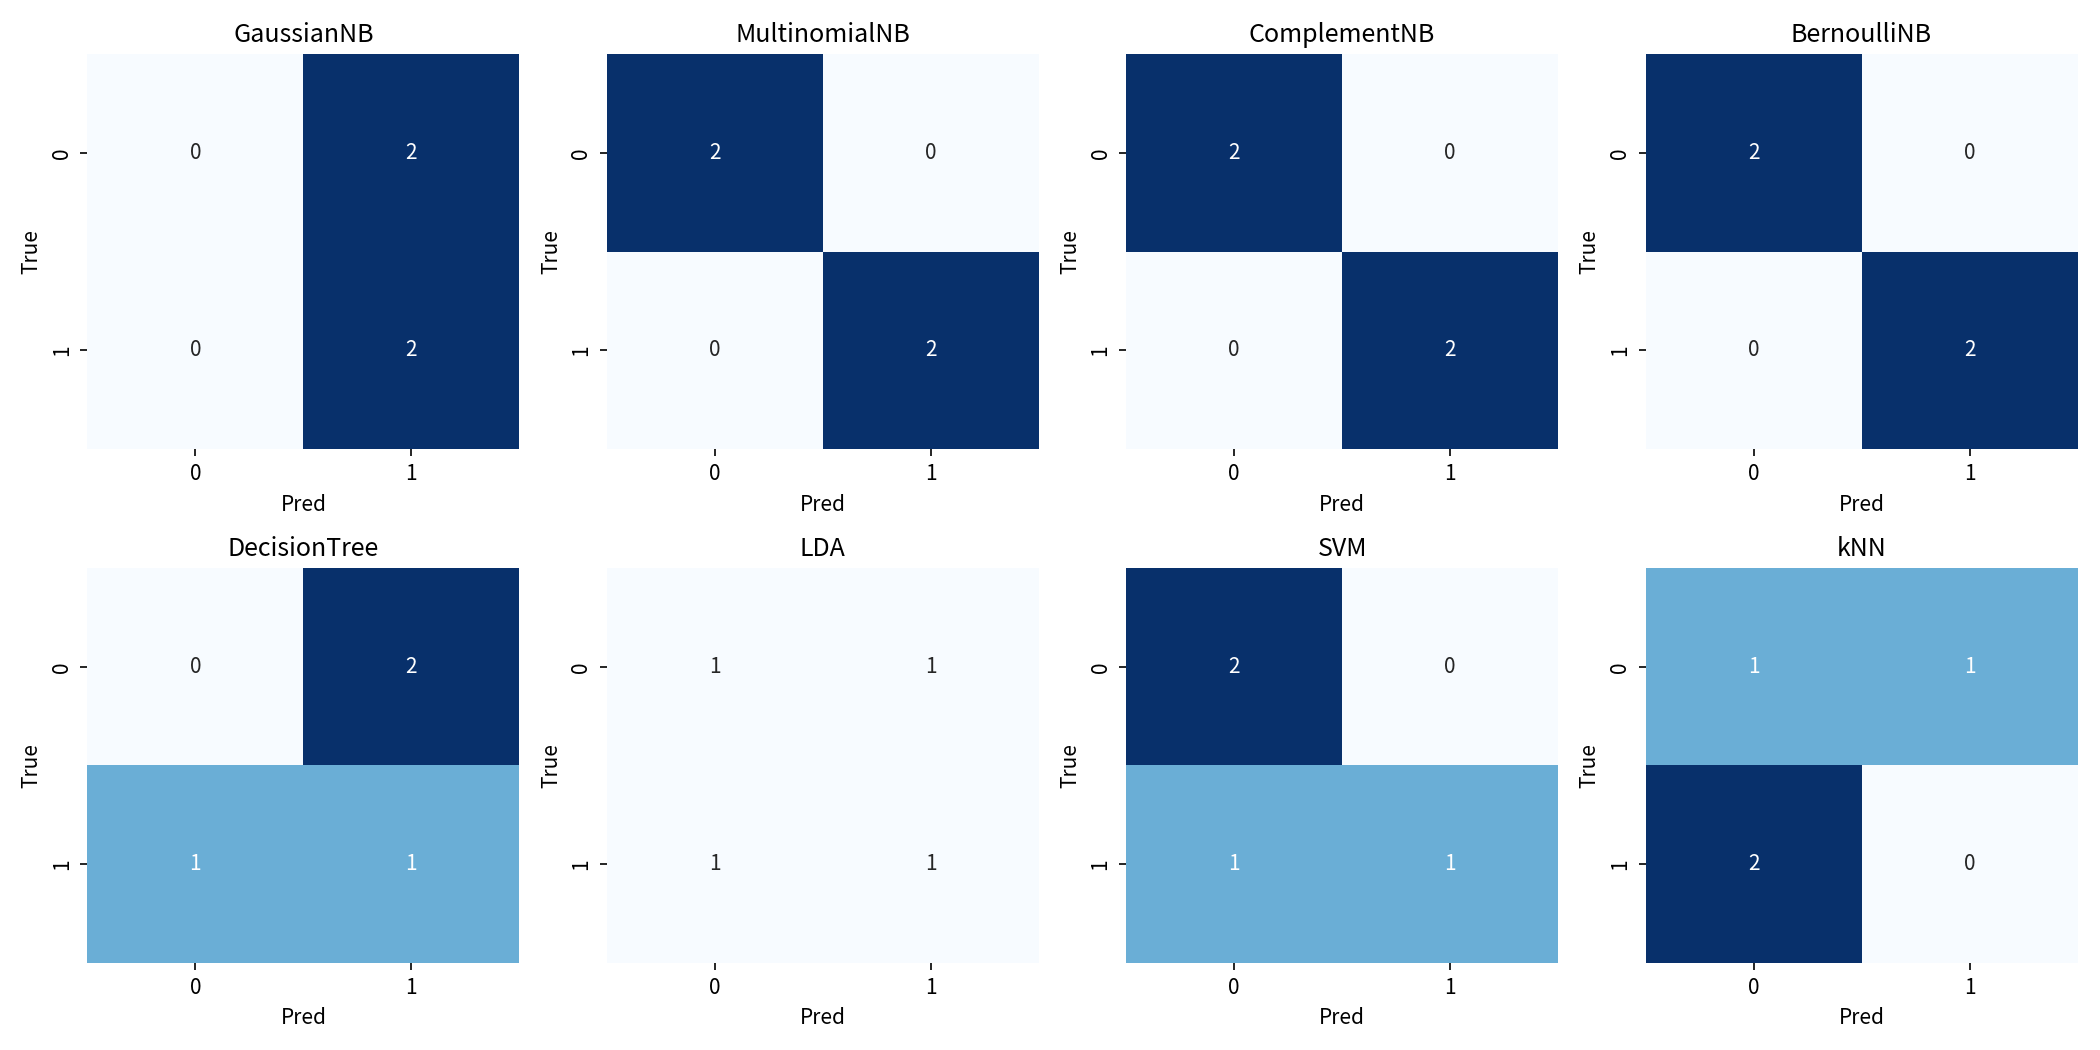

*Рисунок. Матрицы ошибок*


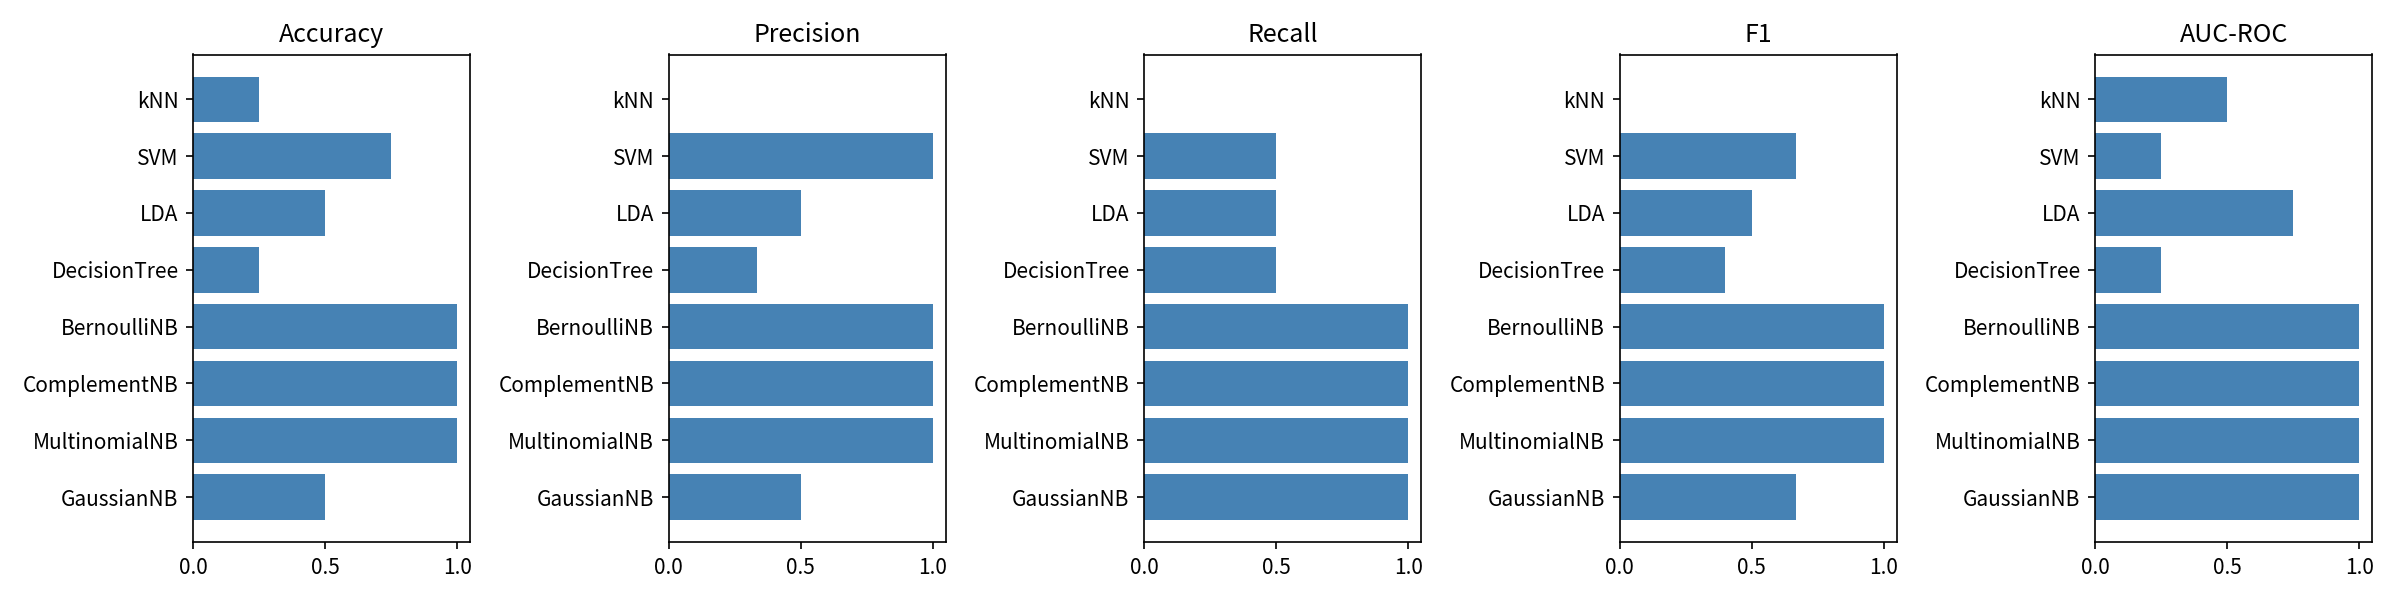

*Рисунок. Сравнение метрик*


## 5. Настройка гиперпараметров

GridSearchCV, 3-fold StratifiedKFold, scoring=`f1`.

| Метод | Сетка |
|:---|:---|
| GaussianNB | var_smoothing ∈ {1e-9…1e-6} |
| DecisionTree | max_depth, criterion, min_samples_split |
| LDA | solver=lsqr, shrinkage ∈ {auto, 0.1, 0.5, 0.9} |
| SVM | C, kernel (linear/rbf), gamma |
| kNN | n_neighbors, weights, metric |


In [ ]:
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
hp_rows = []

def run_grid(name, pipe, grid):
    gs = GridSearchCV(pipe, grid, cv=cv3, scoring="f1", n_jobs=1, error_score=np.nan)
    gs.fit(X_train, y_train)
    pred = gs.predict(X_test)
    proba = gs.predict_proba(X_test)[:, 1]
    row = {"Model": name, "Best_params": str(gs.best_params_),
           "CV_best_f1": gs.best_score_,
           "Test_Accuracy": accuracy_score(y_test, pred),
           "Test_F1": f1_score(y_test, pred, zero_division=0),
           "Test_AUC": roc_auc_score(y_test, proba)}
    hp_rows.append(row)
    print(name, gs.best_params_, "CV_F1", round(gs.best_score_, 3))
    return gs

run_grid("GaussianNB", Pipeline([("prep", preprocessor), ("clf", GaussianNB())]),
         {"clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]})
run_grid("DecisionTree", Pipeline([("prep", preprocessor), ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
         {"clf__max_depth": [2, 3, 5, None], "clf__criterion": ["gini", "entropy"], "clf__min_samples_split": [2, 4]})
run_grid("LDA", Pipeline([("prep", preprocessor), ("clf", LinearDiscriminantAnalysis())]),
         {"clf__solver": ["lsqr"], "clf__shrinkage": ["auto", 0.1, 0.5, 0.9]})
run_grid("SVM", Pipeline([("prep", preprocessor), ("clf", SVC(probability=True, random_state=RANDOM_STATE))]),
         {"clf__C": [0.1, 1, 10], "clf__kernel": ["linear", "rbf"], "clf__gamma": ["scale", "auto"]})
run_grid("kNN", Pipeline([("prep", preprocessor), ("clf", KNeighborsClassifier())]),
         {"clf__n_neighbors": [3, 5, 7], "clf__weights": ["uniform", "distance"], "clf__metric": ["euclidean", "manhattan"]})
hp_df = pd.DataFrame(hp_rows)
display(hp_df)

# Influence plots
ks, scores_k = [], []
for k in [1, 3, 5, 7, 9]:
    pipe = Pipeline([("prep", preprocessor), ("clf", KNeighborsClassifier(n_neighbors=k))])
    scores_k.append(cross_val_score(pipe, X_train, y_train, cv=cv3, scoring="accuracy").mean())
    ks.append(k)
plt.figure(figsize=(6, 4)); plt.plot(ks, scores_k, marker="o")
plt.xlabel("n_neighbors"); plt.ylabel("CV Accuracy"); plt.title("kNN")
plt.tight_layout(); plt.savefig("figures/knn_n_neighbors.png", dpi=150); plt.show()

ds, scores_d, labs = [], [], []
for d in [1, 2, 3, 5, 7, None]:
    pipe = Pipeline([("prep", preprocessor), ("clf", DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE))])
    scores_d.append(cross_val_score(pipe, X_train, y_train, cv=cv3, scoring="accuracy").mean())
    ds.append(d if d else 10); labs.append(str(d))
plt.figure(figsize=(6, 4)); plt.plot(ds, scores_d, marker="o"); plt.xticks(ds, labs)
plt.xlabel("max_depth"); plt.ylabel("CV Accuracy"); plt.title("DecisionTree")
plt.tight_layout(); plt.savefig("figures/dt_max_depth.png", dpi=150); plt.show()


### Результаты GridSearch (сохранённые)

```
Model,Best_params,CV_best_f1,Test_Accuracy,Test_F1,Test_AUC
GaussianNB,{'clf__var_smoothing': 1e-09},0.48888888888888893,0.5,0.6666666666666666,1.0
DecisionTree,"{'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__min_samples_split': 4}",0.48888888888888893,0.25,0.4,0.25
LDA,"{'clf__shrinkage': 0.9, 'clf__solver': 'lsqr'}",0.5777777777777778,0.75,0.6666666666666666,1.0
SVM,"{'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}",0.41269841269841273,0.5,0.5,0.5
kNN,"{'clf__metric': 'euclidean', 'clf__n_neighbors': 3, 'clf__weights': 'uniform'}",0.5111111111111112,0.75,0.6666666666666666,0.875

```


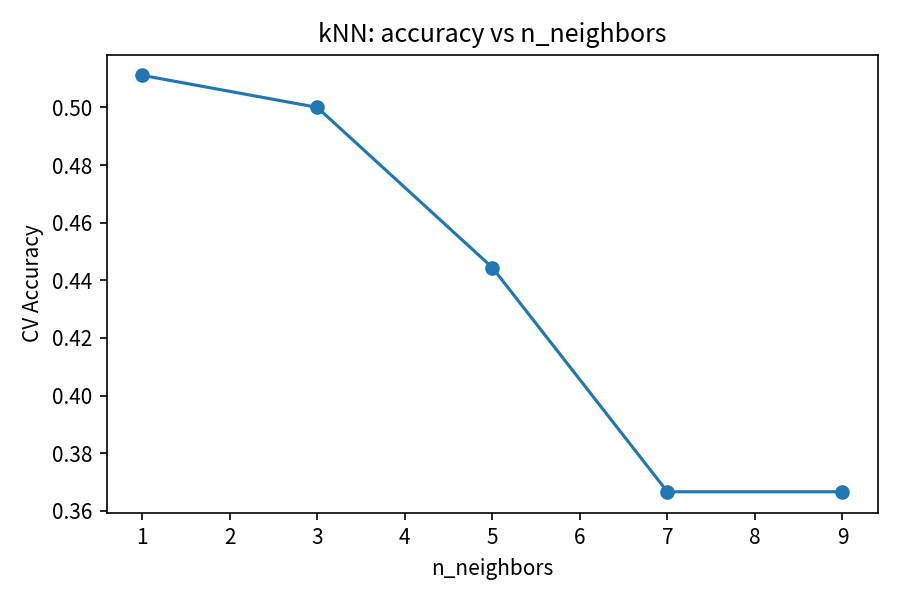

*Рисунок. CV accuracy vs n_neighbors (kNN)*


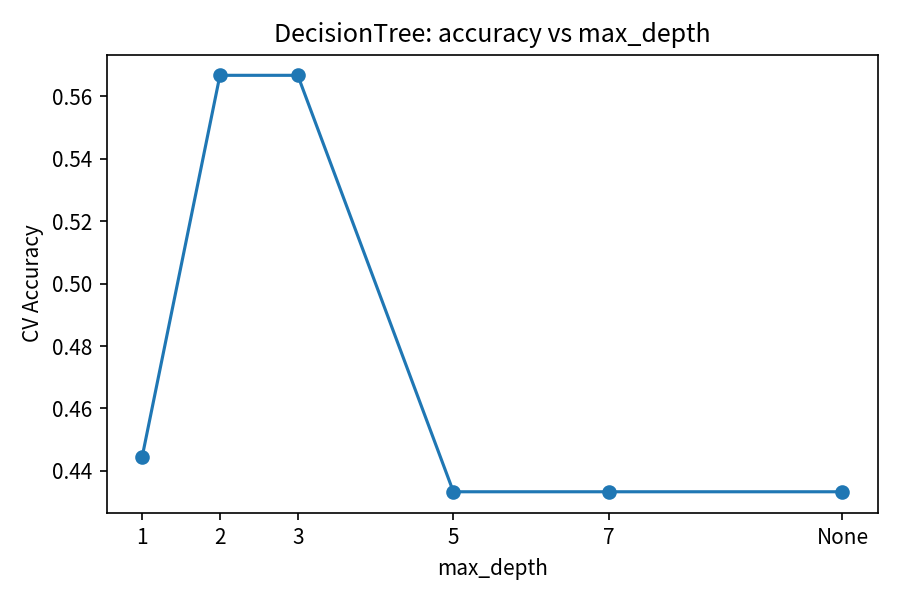

*Рисунок. CV accuracy vs max_depth (Decision Tree)*


**Выводы по HP:** на малой выборке CV-оценки шумные. LDA с сильной shrinkage (0.9) и kNN с k=3 выглядят устойчивее. SVM linear с C=10 — разумный кандидат. Деревья без регуляризации глубины склонны к переобучению.


## 6. Нейронная сеть (TensorFlow/Keras)

**Baseline:** Input(9) → Dense(16, relu) → Dense(1, sigmoid); Adam(lr=0.001); binary_crossentropy; epochs=50, batch=4, validation_split=0.25.

TensorBoard: `log_dir=./logs/baseline`, `histogram_freq=1`.
Запуск: `tensorboard --logdir ./logs/`


In [ ]:
def build_model(n_features, hidden=(16,), activation="relu", lr=0.001, optimizer_name="adam"):
    model = keras.Sequential([layers.Input(shape=(n_features,))])
    for h in hidden:
        model.add(layers.Dense(h, activation=activation))
    model.add(layers.Dense(1, activation="sigmoid"))
    opts = {
        "adam": keras.optimizers.Adam(learning_rate=lr),
        "sgd": keras.optimizers.SGD(learning_rate=lr),
        "rmsprop": keras.optimizers.RMSprop(learning_rate=lr),
    }
    model.compile(optimizer=opts[optimizer_name], loss="binary_crossentropy", metrics=["accuracy"])
    return model

n_feat = X_train_s.shape[1]
tf.random.set_seed(RANDOM_STATE)
baseline = build_model(n_feat)
hist = baseline.fit(
    X_train_s, y_train, epochs=50, batch_size=4, validation_split=0.25, verbose=0,
    callbacks=[keras.callbacks.TensorBoard(log_dir="./logs/baseline", histogram_freq=1)],
)
yprob = baseline.predict(X_test_s, verbose=0).ravel()
ypred = (yprob >= 0.5).astype(int)
print("NN baseline Acc", accuracy_score(y_test, ypred), "F1", f1_score(y_test, ypred, zero_division=0),
      "AUC", roc_auc_score(y_test, yprob))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(hist.history["loss"], label="train"); axes[0].plot(hist.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(hist.history["accuracy"], label="train"); axes[1].plot(hist.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout(); plt.savefig("figures/nn_baseline_curves.png", dpi=150); plt.show()


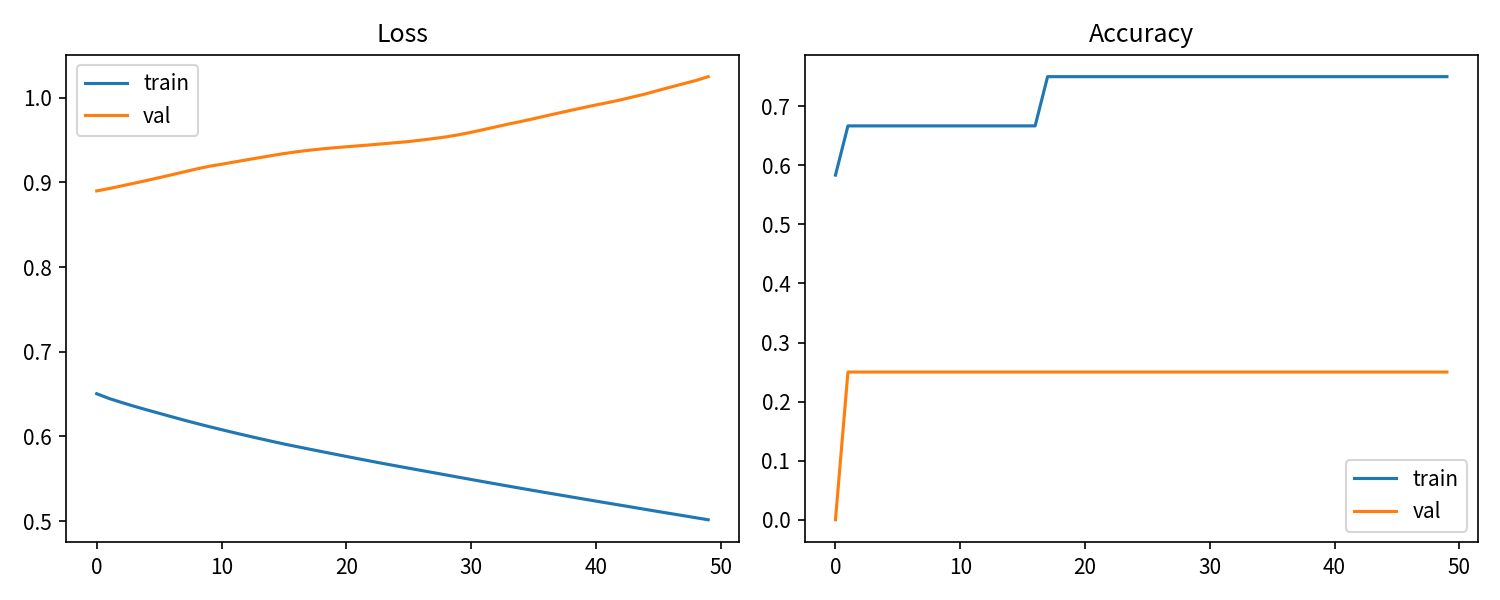

*Рисунок. Кривые обучения baseline NN*


### Эксперименты с гиперпараметрами NN

Варьировались: число нейронов/слоёв, activation (relu/tanh), optimizer (Adam/SGD/RMSprop), batch size.

```
hidden,activation,lr,opt,epochs,batch,val_accuracy,test_accuracy,test_f1,test_auc
"(8,)",relu,0.001,adam,25,4,0.5,0.5,0.5,0.5
"(16,)",relu,0.001,adam,25,4,0.5,0.75,0.6666666666666666,0.5
"(32,)",relu,0.001,adam,25,4,0.5,0.75,0.8,1.0
"(16, 8)",relu,0.001,adam,25,4,0.5,0.75,0.6666666666666666,1.0
"(16,)",tanh,0.001,adam,25,4,0.5,0.25,0.0,0.5
"(16,)",relu,0.01,sgd,25,4,0.5,1.0,1.0,1.0
"(16,)",relu,0.001,rmsprop,25,8,0.0,0.75,0.6666666666666666,1.0

```

На малой выборке кривые val сильно колеблются; возможны и переобучение, и недообучение. Лучшие тестовые F1 в прогонах — у более широкого слоя (32) и SGD с lr=0.01 (нестабильно на 4 test-точках).


### Доп.: CV + Grid (lr × architecture)

3-fold StratifiedKFold; lr ∈ {0.001, 0.01}; arch ∈ {(8,), (16,), (16,8)}.

```
lr,arch,mean_acc,mean_f1,std_f1
0.001,"(8,)",0.6777777777777777,0.7619047619047619,0.13468700594029476
0.001,"(16,)",0.6222222222222222,0.6944444444444443,0.039283710065919325
0.001,"(16, 8)",0.5777777777777778,0.37777777777777777,0.32810717911629783
0.01,"(8,)",0.37777777777777777,0.3333333333333333,0.2721655269759087
0.01,"(16,)",0.3666666666666667,0.30158730158730157,0.23436227079735555
0.01,"(16, 8)",0.4444444444444445,0.41269841269841273,0.29440058715859374

```

Лучшая по mean F1 конфигурация: **lr=0.001, arch=(8,)** (mean_f1 ≈ 0.76 на CV). Она лучше baseline на CV, но test set слишком мал для жёстких выводов.


## 7. Сравнительный анализ

```
Model,Accuracy,Precision,Recall,F1,AUC-ROC
GaussianNB,0.5,0.5,1.0,0.6666666666666666,1.0
MultinomialNB,1.0,1.0,1.0,1.0,1.0
ComplementNB,1.0,1.0,1.0,1.0,1.0
BernoulliNB,1.0,1.0,1.0,1.0,1.0
DecisionTree,0.25,0.3333333333333333,0.5,0.4,0.25
LDA,0.5,0.5,0.5,0.5,0.75
SVM,0.75,1.0,0.5,0.6666666666666666,0.25
kNN,0.25,0.0,0.0,0.0,0.5
NN_baseline,0.25,0.3333333333333333,0.5,0.4,0.25

```


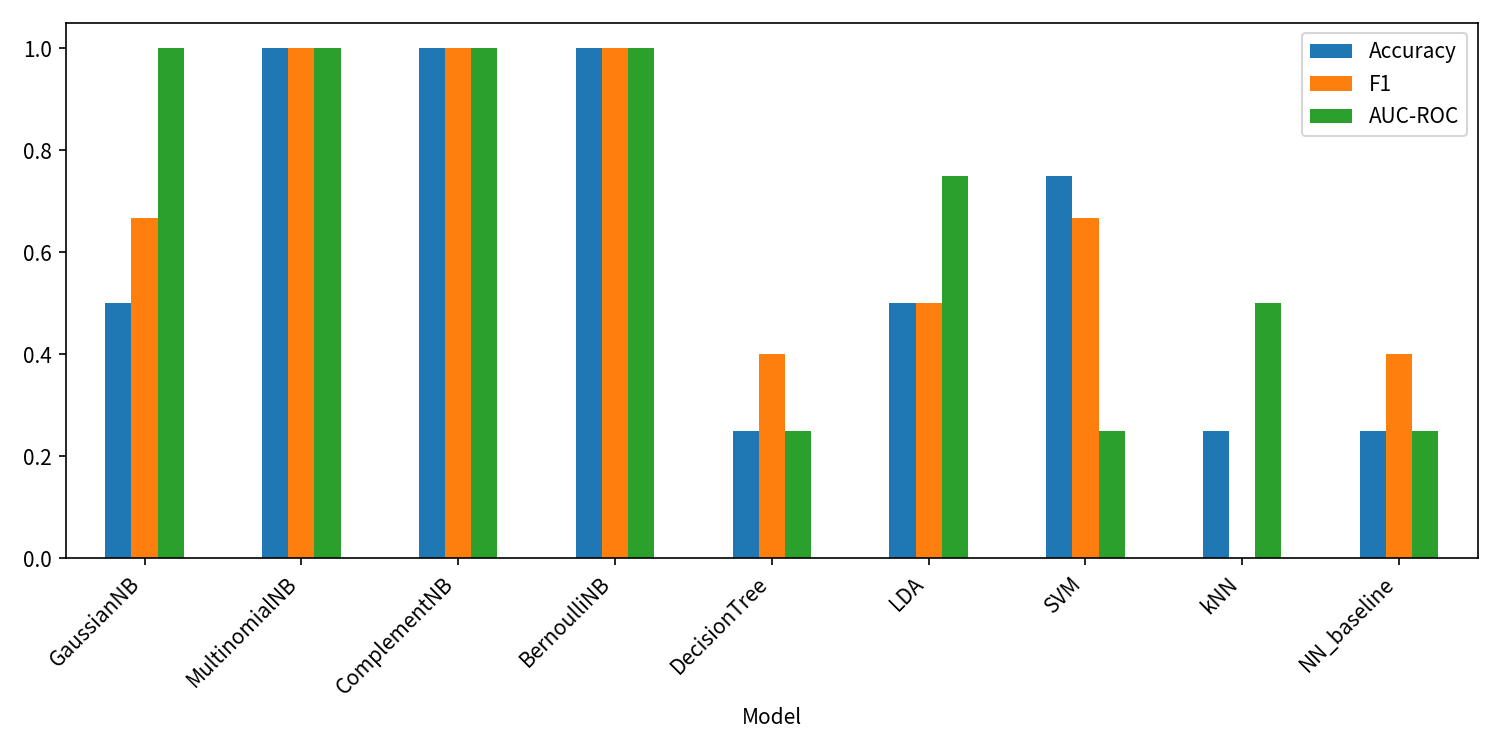

*Рисунок. Итоговое сравнение моделей*


**Вывод о лучшем подходе:**

- На **тестовой выборке из 4 объектов** формально лидируют MultinomialNB / ComplementNB / BernoulliNB (Accuracy=1.0) — это **ненадёжно** из‑за размера test.
- Более осторожная оценка по CV и разнообразию метрик: **LDA (со shrinkage)**, **SVM**, **GaussianNB**, компактная **NN (8 нейронов, lr=0.001)**.
- Для продакшена нужен датасет на порядки больше; текущие цифры — учебная демонстрация пайплайна.

Рекомендация для данного файла: простой **BernoulliNB/ComplementNB** или **LDA+shrinkage** как интерпретируемые baseline; NN — для демонстрации TensorBoard и пайплайна Keras.


## 8. Заключение

1. Датасет маркетинговых кампаний (20 строк) подготовлен: OHE Location, StandardScaler/MinMax, stratify split.
2. Реализованы 8 классических моделей + метрики Accuracy/Precision/Recall/F1/AUC-ROC, ROC и confusion matrices.
3. GridSearchCV для GaussianNB, Tree, LDA, SVM, kNN; построены графики влияния n_neighbors и max_depth.
4. Baseline NN (Dense 16 → sigmoid) + эксперименты по слоям, activation, optimizer; логи TensorBoard в `./logs/`.
5. 3-fold CV × сетка lr/архитектур; лучшая CV-конфигурация — (8,) + lr=0.001.
6. Главный практический вывод: **n=20 критически мало** для устойчивого сравнения; пайплайн готов к масштабированию на больший датасет.
